#### Voice Description Generation with Conditioning

In [1]:
audio_descriptors = {
    "gender": ["male", "female"],
    "reverberation": [
        "very distant-sounding", "distant-sounding", "slightly distant-sounding", "slightly close-sounding", "very close-sounding"
    ],
    "noise": [
        "extremely noisy", "very noisy", "noisy", "slightly noisy", "almost no noise", "very clear"
    ],
    "accent": [
        "American", "British", "Chinese", "Indian", "Australian", "Spanish", "French", "German", "Italian", "Russian", "Japanese"
    ],
    "emotion": [
        "angry", "awe", "bored", "calm", "confused", "neutral", "desirous", "disgusted", "enunciated", "fearful", "happy", "laughing", "projected", "sad", "sarcastic", "sleepy", "sympathetic", "whispering"
    ]
}

Finds numeric digits in the string and converts them to English words.

In [8]:
from num2words import num2words
import re

def convert_digits_to_words(text):
    if not isinstance(text, str):
        return ""
    # Regex finds exact number boundaries to avoid breaking partial strings
    return re.sub(r'\b\d+\b', lambda x: num2words(int(x.group())), text)

Returns logically appropriate subsets of tone, pace, and pitch based on the energy/nature of the selected emotion.

In [3]:
import random

def get_constrained_features(emotion):
    low_energy_emotions = ["bored", "calm", "sad", "sleepy", "whispering"]
    high_energy_emotions = ["angry", "fearful", "happy", "laughing", "projected"]
    if emotion in low_energy_emotions:
        # Prevent fast pacing, high pitches, and extreme animation
        tones = ["very monotone", "monotone", "slightly expressive and animated"]
        paces = ["very slowly", "slowly", "slightly slowly", "at a moderate speed"]
        pitches = ["very low-pitch", "low-pitch", "slightly low-pitch", "moderate pitch"]
    elif emotion in high_energy_emotions:
        # Prevent monotone, slow pacing (angry can still be low pitch, so we keep most pitches)
        tones = ["slightly expressive and animated", "expressive and animated", "very expressive and animated"]
        paces = ["at a moderate speed", "slightly fast", "fast", "very fast"]
        pitches = ["low-pitch", "slightly low-pitch", "moderate pitch", "slightly high-pitch", "high-pitch", "very high-pitch"]
    else:
        # Flexible/Neutral emotions (awe, confused, disgusted, sarcastic, etc.)
        # Exclude only the absolute extremes to maintain a natural sound
        tones = ["monotone", "slightly expressive and animated", "expressive and animated"]
        paces = ["slowly", "slightly slowly", "at a moderate speed", "slightly fast", "fast"]
        pitches = ["low-pitch", "slightly low-pitch", "moderate pitch", "slightly high-pitch", "high-pitch"]
    return random.choice(tones), random.choice(paces), random.choice(pitches)

In [4]:
def generate_parler_descriptions(descriptors):
    generated_prompts = []
    for _ in range(3):
        # 1. Select independent traits
        gender = random.choice(descriptors["gender"])
        reverb = random.choice(descriptors["reverberation"])
        noise = random.choice(descriptors["noise"])
        accent = random.choice(descriptors["accent"])
        emotion = random.choice(descriptors["emotion"])
        # 2. Select constrained traits
        tone, pace, pitch = get_constrained_features(emotion)
        # 3. Define Natural Language Templates integrating the Emotion
        if emotion == "whispering":
            raw_prompt = f"A {gender} speaker with a {accent} accent whispers {pace}, with a {tone} delivery and {pitch} voice. The recording is {noise} and {reverb}."
        else:
            raw_prompt = f"A {gender} speaker with a {accent} accent speaks {pace} in a {emotion} tone, with a {tone} delivery and {pitch} voice. The recording is {noise} and {reverb}."
        # Clean up any weird spacing left by omitted pace/pitch strings
        clean_prompt = " ".join(raw_prompt.split()).replace(" ,", ",").replace(" .", ".")
        generated_prompts.append(clean_prompt)
    return generated_prompts

Simulating 2 different user commands

In [5]:
for i in range(2):
    print(f"--- Variations for Command {i+1} ---")
    prompts_list = generate_parler_descriptions(audio_descriptors)
    for j, prompt in enumerate(prompts_list):
        print(f"Template {j+1}: {prompt}")

--- Variations for Command 1 ---
Template 1: A male speaker with a American accent speaks at a moderate speed in a desirous tone, with a slightly expressive and animated delivery and low-pitch voice. The recording is slightly noisy and slightly close-sounding.
Template 2: A male speaker with a Russian accent speaks very slowly in a sleepy tone, with a slightly expressive and animated delivery and slightly low-pitch voice. The recording is very clear and very distant-sounding.
Template 3: A female speaker with a Chinese accent speaks slightly fast in a sympathetic tone, with a slightly expressive and animated delivery and high-pitch voice. The recording is extremely noisy and slightly close-sounding.
--- Variations for Command 2 ---
Template 1: A female speaker with a Italian accent speaks at a moderate speed in a sad tone, with a slightly expressive and animated delivery and slightly low-pitch voice. The recording is very noisy and very distant-sounding.
Template 2: A female speaker wi

Reads the base domotic commands from a local CSV file, and applies combinatorial voice conditioning.

In [6]:
import pandas as pd
import csv
import os

def create_prompts_dataset(input_csv, output_csv):
    try:
        df_base = pd.read_csv(input_csv)
    except FileNotFoundError:
        print(f"Error: Could not find {input_csv}.")
        return

    output_rows = []
    # Iterate through the dataframe using the explicit row index as the cmd_id
    for cmd_id, row in df_base.iterrows():
        user_command = row.get("User_Command", "")
        # Skip empty rows
        if not isinstance(user_command, str) or not user_command.strip():
            continue
        # Convert numeric digits to textual words
        user_command = convert_digits_to_words(user_command)
        # Generate the 3 unique description prompts
        prompts_list = generate_parler_descriptions(audio_descriptors)
        # Append 3 separate rows linking back to the same cmd_idx
        for prompt in prompts_list:
            output_rows.append({
                "cmd_id": cmd_id,
                "User_Command": user_command, # Included for easier debugging/tracking
                "Voice_Description": prompt
            })
    os.makedirs("./data", exist_ok=True)
    df_output = pd.DataFrame(output_rows)
    df_output.index.name = "prompt_id"
    df_output.to_csv(
        output_csv,
        index=True,
        quoting=csv.QUOTE_ALL,
        escapechar='\\'
    )

In [9]:
create_prompts_dataset("./data/cleaned_raw_train.csv", "./data/description_prompts_train.csv")
create_prompts_dataset("./data/cleaned_raw_test.csv", "./data/description_prompts_test.csv")

#### Dataset Evaluation & Visualization

In [17]:
# 1. Define the Trait Vocabulary for Extraction
# These match the exact strings used in the generation script
EVAL_DICTIONARY = {
    "Gender": ["male", "female"],
    "Accent": ["American", "British", "Chinese", "Indian", "Australian", "Spanish", "French", "German", "Italian", "Russian", "Japanese"],
    "Emotion": ["angry", "awe", "bored", "calm", "confused", "neutral", "desirous", "disgusted", "enunciated", "fearful", "happy", "laughing", "projected", "sad", "sarcastic", "sleepy", "sympathetic", "whispers"],
    "Noise_Level": ["extremely noisy", "very noisy", "noisy", "slightly noisy", "almost no noise", "very clear", "poor recording", "bad recording", "good recording", "excellent recording"]
}

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def extract_traits(prompt, category_vocab):
    # Sort vocabulary by length descending so longer phrases are matched first
    # (e.g., checks "woman" before "man", and "very noisy" before "noisy")
    sorted_vocab = sorted(category_vocab, key=len, reverse=True)
    for trait in sorted_vocab:
        # Use regex with word boundaries (\b) to match exact words, ignoring case
        # This ensures 'man' does not trigger inside 'woman'
        pattern = r'\b' + re.escape(trait) + r'\b'
        if re.search(pattern, str(prompt), re.IGNORECASE):
            return trait
    return "Unknown"

# 2. Evaluation Logic & Distribution Parsing
def evaluate_dataset_diversity(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: Could not find {csv_path}. Please run the generation script first.")
        return None

    # Extract traits back out of the natural language strings
    for category, vocab in EVAL_DICTIONARY.items():
        df[category] = df["Voice_Description"].apply(lambda x: extract_traits(x, vocab))
    # 3. Statistical Variance Check
    # To prove "near-uniform distribution", we calculate the Coefficient of Variation (CV).
    # A low CV (< 0.15) mathematically proves that no single trait dominates the dataset.
    print("--- Statistical Distribution Proof (Target: Near-Uniform) ---")
    for category in EVAL_DICTIONARY.keys():
        counts = df[category].value_counts()
        mean_freq = counts.mean()
        std_freq = counts.std() if len(counts) > 1 else 0
        cv = std_freq / mean_freq if mean_freq > 0 else 0
        print(f"{category.upper()}:")
        print(f"  - Unique Categories Found: {len(counts)}")
        print(f"  - Mean Samples per Category: {mean_freq:.1f}")
        print(f"  - Coefficient of Variation (CV): {cv:.3f} " + ("(Perfectly Balanced)" if cv < 0.15 else "(High Variance)"))
    return df

def plot_dataset_diversity(df):
    if df is None or df.empty:
        print("Error: Invalid DataFrame provided for plotting.")
        return

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Evaluation 1.1: Acoustic Trait Distribution Analysis', fontsize=18, fontweight='bold', y=0.98)

    # Plot 1: Gender (Pie Chart for binary traits)
    gender_counts = df["Gender"].value_counts()
    axes[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
    axes[0, 0].set_title('Speaker Gender Distribution', fontsize=14, fontweight='bold')

    # Plot 2: Emotion (Bar Chart)
    sns.countplot(data=df, y="Emotion", ax=axes[0, 1], order=df["Emotion"].value_counts().index, palette="viridis", hue="Emotion", legend=False)
    axes[0, 1].set_title('Injected Emotional States', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Number of Prompts')
    axes[0, 1].set_ylabel('')

    # Plot 3: Accent (Bar Chart)
    sns.countplot(data=df, y="Accent", ax=axes[1, 0], order=df["Accent"].value_counts().index, palette="magma", hue="Accent", legend=False)
    axes[1, 0].set_title('Speaker Accent Diversity', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Number of Prompts')
    axes[1, 0].set_ylabel('')

    # Plot 4: Noise / Channel Conditions
    sns.countplot(data=df, y="Noise_Level", ax=axes[1, 1], order=df["Noise_Level"].value_counts().index, palette="coolwarm", hue="Noise_Level", legend=False)
    axes[1, 1].set_title('Channel Noise Conditions', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Number of Prompts')
    axes[1, 1].set_ylabel('')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

--- Statistical Distribution Proof (Target: Near-Uniform) ---
GENDER:
  - Unique Categories Found: 2
  - Mean Samples per Category: 20148.0
  - Coefficient of Variation (CV): 0.009 (Perfectly Balanced)
ACCENT:
  - Unique Categories Found: 11
  - Mean Samples per Category: 3663.3
  - Coefficient of Variation (CV): 0.018 (Perfectly Balanced)
EMOTION:
  - Unique Categories Found: 18
  - Mean Samples per Category: 2238.7
  - Coefficient of Variation (CV): 0.022 (Perfectly Balanced)
NOISE_LEVEL:
  - Unique Categories Found: 6
  - Mean Samples per Category: 6716.0
  - Coefficient of Variation (CV): 0.017 (Perfectly Balanced)


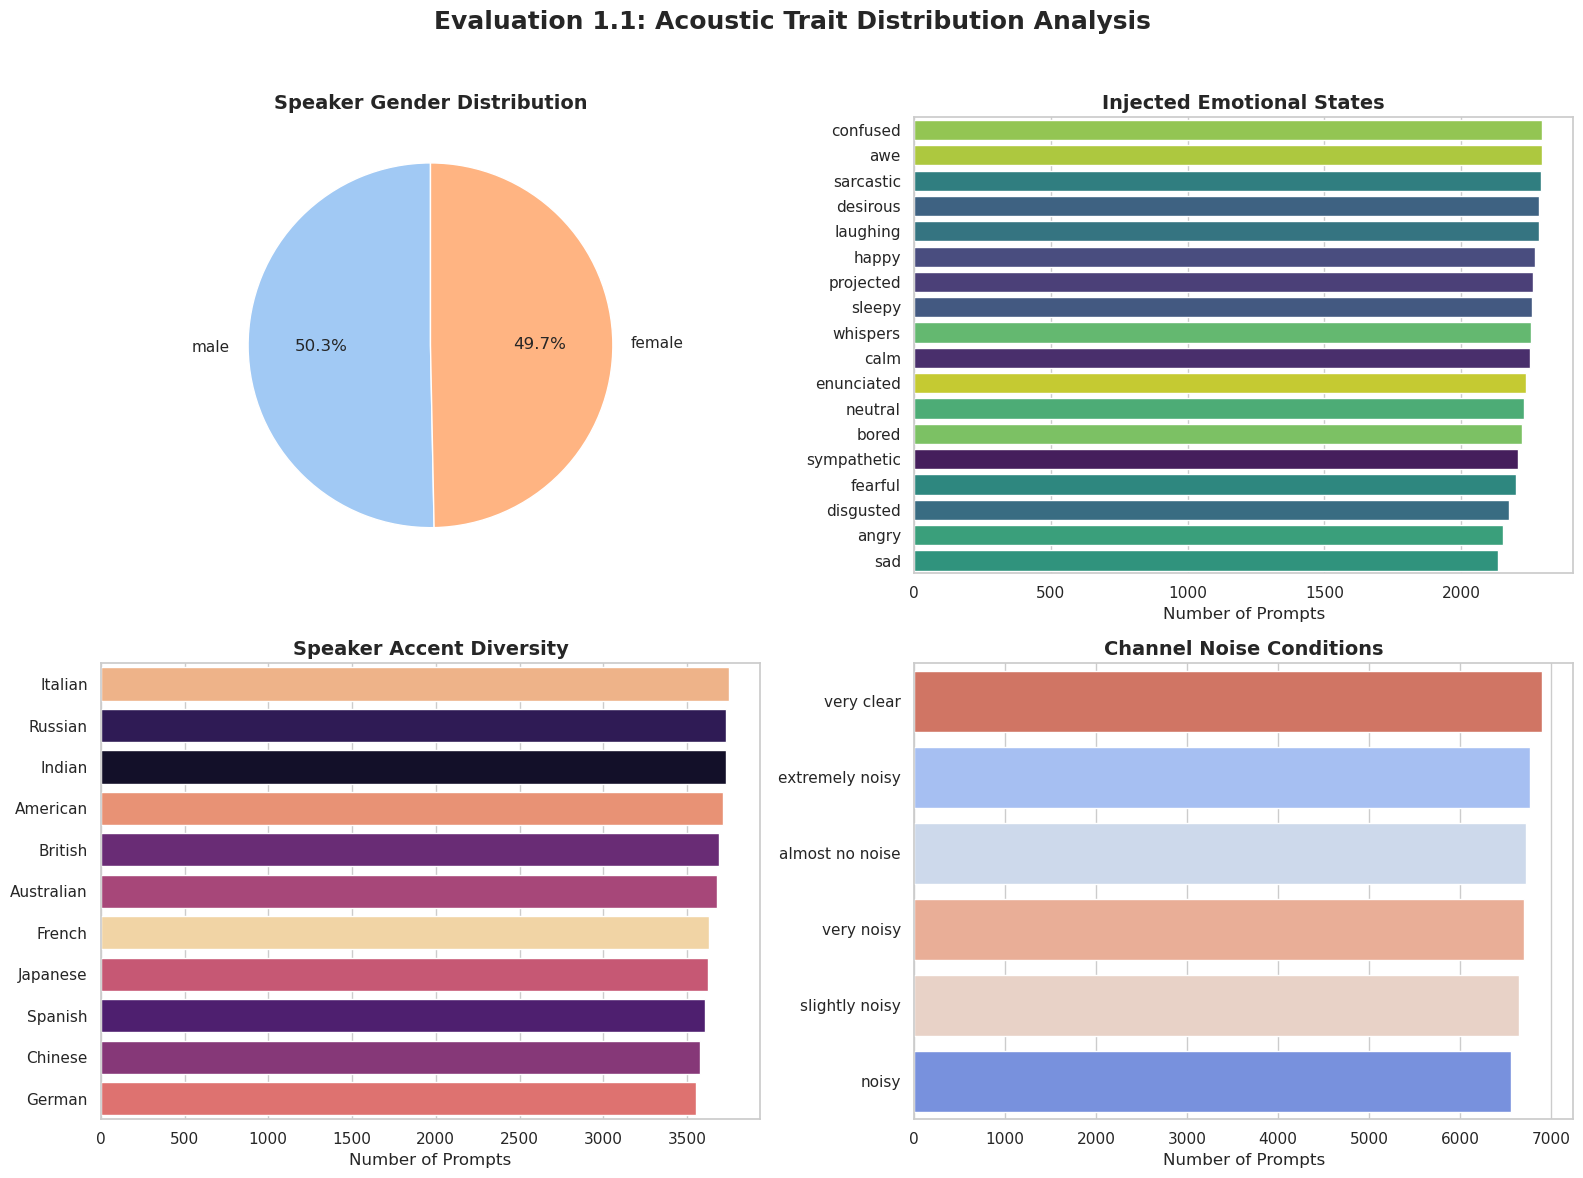

In [18]:
plot_dataset_diversity(evaluate_dataset_diversity("./data/description_prompts_train.csv"))

--- Statistical Distribution Proof (Target: Near-Uniform) ---
GENDER:
  - Unique Categories Found: 2
  - Mean Samples per Category: 5325.0
  - Coefficient of Variation (CV): 0.013 (Perfectly Balanced)
ACCENT:
  - Unique Categories Found: 11
  - Mean Samples per Category: 968.2
  - Coefficient of Variation (CV): 0.026 (Perfectly Balanced)
EMOTION:
  - Unique Categories Found: 18
  - Mean Samples per Category: 591.7
  - Coefficient of Variation (CV): 0.039 (Perfectly Balanced)
NOISE_LEVEL:
  - Unique Categories Found: 6
  - Mean Samples per Category: 1775.0
  - Coefficient of Variation (CV): 0.015 (Perfectly Balanced)


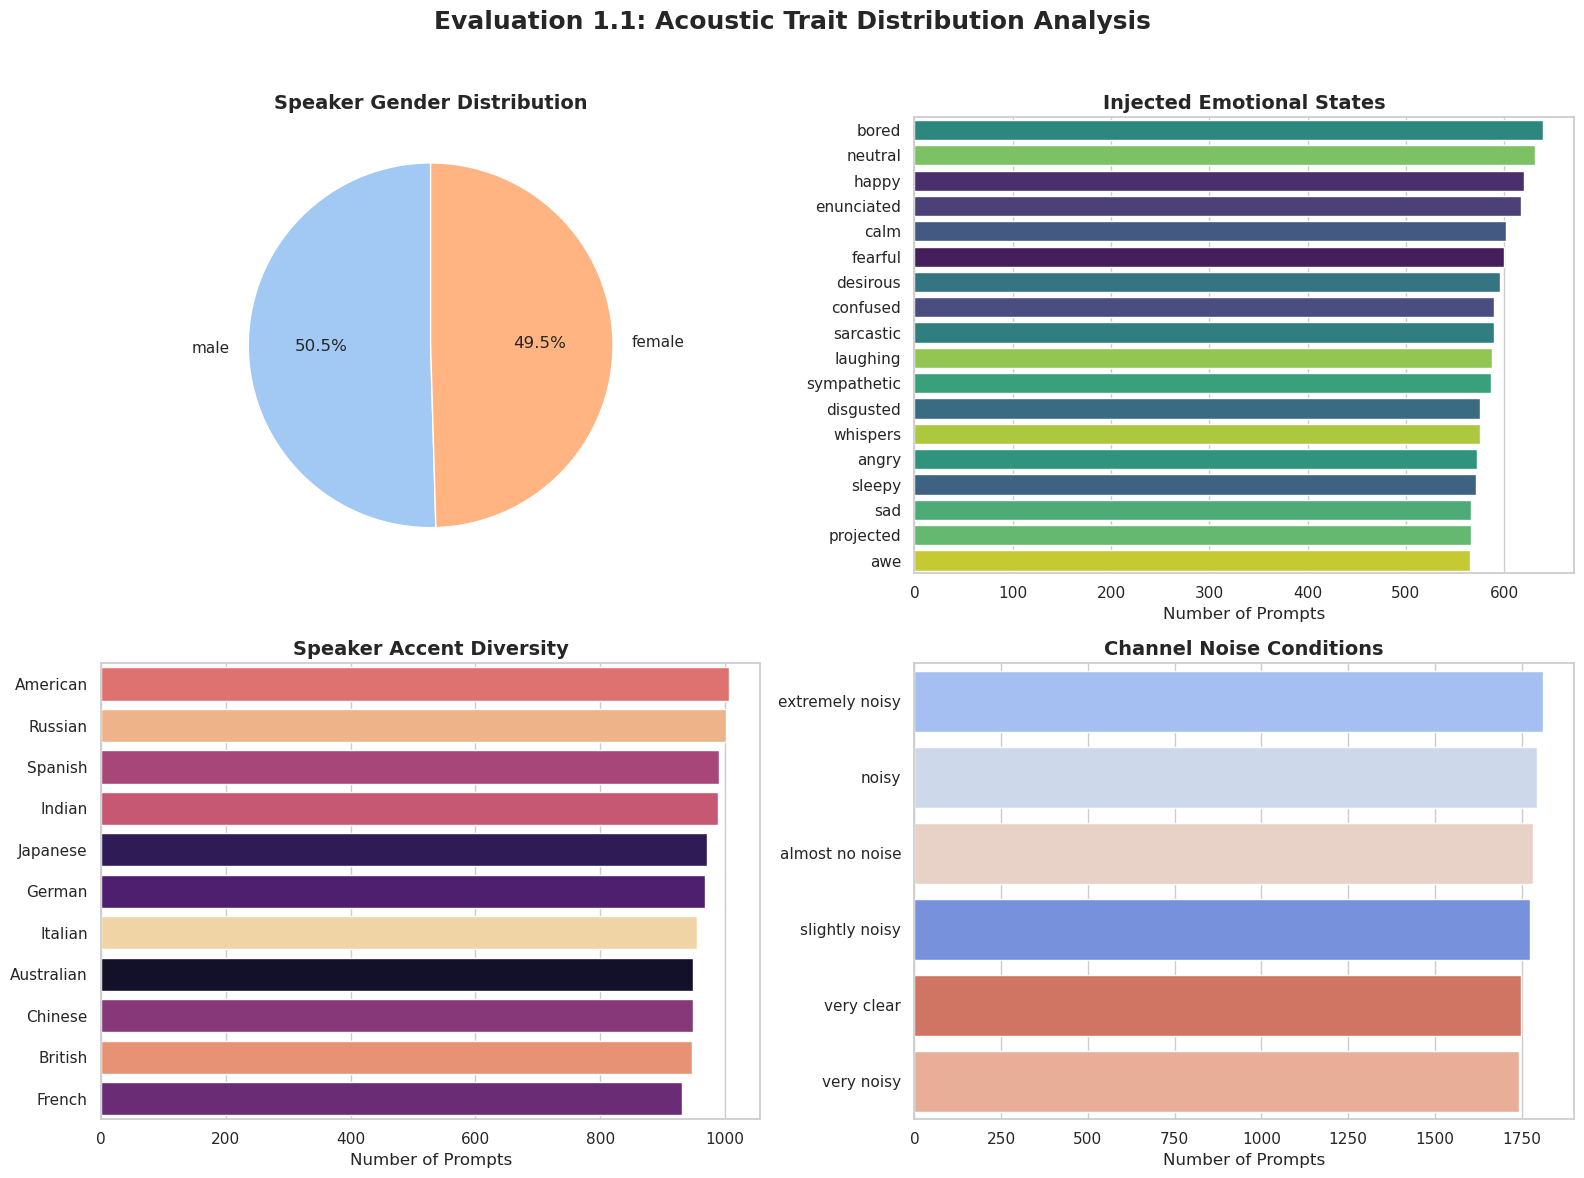

In [19]:
plot_dataset_diversity(evaluate_dataset_diversity("./data/description_prompts_test.csv"))